# Data Extraction

## hivejdbc

In [2]:
!pip install hivejdbc

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 448 kB 1.6 MB/s            


In [14]:
from hivejdbc import connect
import os
import pandas as pd

with open("../secrets/.hive.pass", "r") as f:
    password = f.read().strip()

conn = connect(
    host='hadoop-03.uni.innopolis.ru',
    port=10001,
    driver="/shared/hive-jdbc-3.1.3-standalone.jar",
    database='team13_projectdb_hive',
    user='team13',
    password=password
)

cur = conn.cursor()

In [15]:
cur.execute("SHOW TABLES")
cur.fetchall()

[('fact_job_applications_opt',)]

In [16]:
query = """
SELECT *
FROM fact_job_applications_opt
WHERE fact_id IS NOT NULL
LIMIT 5000
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,88,89,90,91,92,93,94,95,96,97
0,2692838,220341869,1,622,VINCENT AVENUE,5484,9,2078308,SI,U,...,None,None,None,None,None,None,None,None,None,None
1,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [8]:
cur.execute("DESCRIBE fact_job_applications_opt")
cols = [row[0] for row in cur.fetchall() if row[0] and not row[0].startswith("#")]
print(len(cols))

98


In [9]:
df.columns = cols[:len(df.columns)]

In [10]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 98 columns):
fact_id                          1 non-null object
job_number                       1 non-null object
doc_number                       1 non-null object
house_number                     1 non-null object
street_name                      1 non-null object
block                            1 non-null object
lot                              1 non-null object
bin_number                       1 non-null object
job_type                         1 non-null object
job_status                       1 non-null object
job_status_descr                 1 non-null object
latest_action_date               1 non-null object
building_type                    1 non-null object
community_board                  1 non-null object
cluster                          1 non-null object
landmarked                       1 non-null object
adult_estab                      0 non-null object
loft_board                

,fact_id,job_number,doc_number,house_number,street_name,block,lot,bin_number,job_type,job_status,...,building_class,job_no_good_count,gis_latitude,gis_longitude,gis_council_district,gis_census_tract,gis_nta_name,gis_bin,created_at,borough
0,2692838,220341869,1,622,VINCENT AVENUE,5484,9,2078308,SI,U,...,None,None,None,None,None,None,None,None,None,None
1,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,None,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [11]:
df['job_status'].value_counts()
df['borough'].value_counts()
df['job_type'].value_counts()

SI    1
Name: job_type, dtype: int64

JDBC + Hive cursor are not reading the table well, let's try another method

## PySpark
Due to problems with hivejdbc, we'll try using PySpark.

In [1]:
from pyspark.sql import SparkSession

warehouse = "project/hive/warehouse"

spark = SparkSession.builder \
    .appName("EDA") \
    .config("spark.sql.catalogImplementation", "hive") \
    .config("hive.metastore.uris", "thrift://hadoop-02.uni.innopolis.ru:9883") \
    .config("spark.sql.warehouse.dir", warehouse) \
    .enableHiveSupport() \
    .getOrCreate()

In [4]:
spark.sql("SHOW DATABASES").show()
spark.sql("USE team13_projectdb_hive").show()
spark.sql("SHOW TABLES").show()

+--------------------+
|           namespace|
+--------------------+
|             default|
|             retake1|
|             root_db|
|                show|
|    team00_projectdb|
|     team0_projectdb|
|             team0db|
|            team0db1|
|            team0db2|
|    team11_projectdb|
|           team12_db|
|team12_hive_proje...|
|    team12_projectdb|
|    team13_projectdb|
|team13_projectdb_...|
|    team14_projectdb|
|    team15_projectdb|
|    team16_projectdb|
|    team17_projectdb|
|    team18_projectdb|
+--------------------+
only showing top 20 rows

++
||
++
++

+--------------------+--------------------+-----------+
|           namespace|           tableName|isTemporary|
+--------------------+--------------------+-----------+
|team13_projectdb_...|fact_job_applicat...|      false|
+--------------------+--------------------+-----------+



In [7]:
df = spark.sql("""
SELECT *
FROM team13_projectdb_hive.fact_job_applications_opt
""")

In [9]:
df.printSchema()
df.count()

root
 |-- fact_id: long (nullable = true)
 |-- job_number: long (nullable = true)
 |-- doc_number: integer (nullable = true)
 |-- house_number: string (nullable = true)
 |-- street_name: string (nullable = true)
 |-- block: integer (nullable = true)
 |-- lot: integer (nullable = true)
 |-- bin_number: long (nullable = true)
 |-- job_type: string (nullable = true)
 |-- job_status: string (nullable = true)
 |-- job_status_descr: string (nullable = true)
 |-- latest_action_date: date (nullable = true)
 |-- building_type: string (nullable = true)
 |-- community_board: string (nullable = true)
 |-- cluster: string (nullable = true)
 |-- landmarked: string (nullable = true)
 |-- adult_estab: string (nullable = true)
 |-- loft_board: string (nullable = true)
 |-- city_owned: string (nullable = true)
 |-- little_e: string (nullable = true)
 |-- pc_filed: string (nullable = true)
 |-- efiling_filed: string (nullable = true)
 |-- plumbing: string (nullable = true)
 |-- mechanical: string (nullab

2714628

# Describe Data 
Examine the "surface" properties of the acquired data

## Location
columns: borough, city, zip, community_board,
gis_council_district, gis_census_tract, gis_nta_name,
gis_latitude, gis_longitude

In [10]:
df.groupBy("borough").count().orderBy("count", ascending=False).show()

+-------------+-------+
|      borough|  count|
+-------------+-------+
|    MANHATTAN|1112802|
|     BROOKLYN| 629254|
|       QUEENS| 560090|
|        BRONX| 232063|
|STATEN ISLAND| 180419|
+-------------+-------+



In [11]:
df.select("borough", "city", "zip").describe().show()

+-------+-------------+----------+--------------------+
|summary|      borough|      city|                 zip|
+-------+-------------+----------+--------------------+
|  count|      2714628|       155|                 153|
|   mean|         null|      null|  1399965.0065359478|
| stddev|         null|      null|1.7182815016979087E7|
|    min|        BRONX|   ARVERNE|               02895|
|    max|STATEN ISLAND|WOONSECKET|           212550500|
+-------+-------------+----------+--------------------+



In [12]:
df.select("gis_latitude", "gis_longitude").describe().show()

+-------+-------------------+-------------------+
|summary|       gis_latitude|      gis_longitude|
+-------+-------------------+-------------------+
|  count|            2705778|            2705778|
|   mean|  40.72353797227508| -73.94711650457387|
| stddev|0.07324195590131082|0.08605174098205336|
|    min|          40.498807|         -74.254897|
|    max|          40.913711|         -73.700376|
+-------+-------------------+-------------------+



## Building characteristics
columns: building_type, building_class, job_type

In [14]:
df.groupBy("building_type").count().orderBy("count", ascending=False).show()
df.groupBy("job_type").count().show()
df.groupBy("building_class").count().show()

+-------------+-------+
|building_type|  count|
+-------------+-------+
|       OTHERS|2073989|
| 1-2-3 FAMILY| 640639|
+-------------+-------+

+--------+-------+
|job_type|  count|
+--------+-------+
|      SC|  13785|
|      A2|1677057|
|      DM|  80346|
|      SI|  19008|
|      NB| 199890|
|      A3| 470955|
|      A1| 219973|
|      PA|  33614|
+--------+-------+

+--------------+-----+
|building_class|count|
+--------------+-----+
|            Z9| 3405|
|            C6|22071|
|            U0|  799|
|            A9|12269|
|            H6|  866|
|            D7|56199|
|            W6|14075|
|            D5| 6283|
|            U2| 2964|
|            F2|  707|
|            V3|  291|
|            A6|  669|
|            K8| 1844|
|            E9| 9499|
|            T9|  776|
|            M4|  687|
|            V0|16881|
|            I5| 5355|
|            VG|  109|
|            H1| 6832|
+--------------+-----+
only showing top 20 rows



## Dimensions / Areas
columns: existing_zoning_sqft, proposed_zoning_sqft,
enlargement_sqft, total_construction_floor_area,
street_frontage

In [15]:
from pyspark.sql.functions import col

df_num = df \
    .withColumn("existing_zoning_sqft", col("existing_zoning_sqft").cast("double")) \
    .withColumn("proposed_zoning_sqft", col("proposed_zoning_sqft").cast("double")) \
    .withColumn("enlargement_sqft", col("enlargement_sqft").cast("double")) \
    .withColumn("total_construction_floor_area", col("total_construction_floor_area").cast("double")) \
    .withColumn("street_frontage", col("street_frontage").cast("double"))

In [16]:
df_num.select(
    "existing_zoning_sqft",
    "proposed_zoning_sqft",
    "enlargement_sqft",
    "total_construction_floor_area",
    "street_frontage"
).describe().show()

+-------+--------------------+--------------------+-----------------+-----------------------------+-----------------+
|summary|existing_zoning_sqft|proposed_zoning_sqft| enlargement_sqft|total_construction_floor_area|  street_frontage|
+-------+--------------------+--------------------+-----------------+-----------------------------+-----------------+
|  count|             2714628|             2714628|          2714628|                      2714628|          2714628|
|   mean|  1338.1132508763633|  1985.2808034839395| 86.1154073412637|           3603.7147244484327|6.020537620624262|
| stddev|  58518.400365947935|   65975.04219389896|13955.95682146423|           1251391.6120902407|173.6300355847349|
|    min|                 0.0|                 0.0|             -9.0|                          0.0|              0.0|
|    max|         2.9214765E7|         2.9214765E7|      2.2304116E7|                 9.99999999E8|          98558.0|
+-------+--------------------+--------------------+-----

In [35]:
from pyspark.sql.functions import count, when

df_num.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in [
        "existing_zoning_sqft",
        "proposed_zoning_sqft",
        "enlargement_sqft",
        "total_construction_floor_area",
        "street_frontage"
    ]
]).show()

+--------------------+--------------------+----------------+-----------------------------+---------------+
|existing_zoning_sqft|proposed_zoning_sqft|enlargement_sqft|total_construction_floor_area|street_frontage|
+--------------------+--------------------+----------------+-----------------------------+---------------+
|                   0|                   0|               0|                            0|              0|
+--------------------+--------------------+----------------+-----------------------------+---------------+



## Finance
columns: initial_cost, total_est_fee, fee_status

In [18]:
df_fin = df_num \
    .withColumn("initial_cost", col("initial_cost").cast("double")) \
    .withColumn("total_est_fee", col("total_est_fee").cast("double"))

In [19]:
df_fin.select("initial_cost", "total_est_fee").describe().show()

+-------+------------+-------------+
|summary|initial_cost|total_est_fee|
+-------+------------+-------------+
|  count|           0|            0|
|   mean|        null|         null|
| stddev|        null|         null|
|    min|        null|         null|
|    max|        null|         null|
+-------+------------+-------------+



In [38]:
df.select("initial_cost", "existing_zoning_sqft", "proposed_zoning_sqft", "total_construction_floor_area").show(20)

+------------+--------------------+--------------------+-----------------------------+
|initial_cost|existing_zoning_sqft|proposed_zoning_sqft|total_construction_floor_area|
+------------+--------------------+--------------------+-----------------------------+
|        null|                0.00|                0.00|                         0.00|
|        null|                0.00|                0.00|                         0.00|
|        null|                0.00|                0.00|                         0.00|
|        null|                0.00|                0.00|                         0.00|
|        null|                0.00|                0.00|                         0.00|
|        null|                0.00|             6451.00|                      8602.00|
|        null|                0.00|                0.00|                         0.00|
|        null|                0.00|                0.00|                         0.00|
|        null|                0.00|        

## Time
columns: latest_action_date, pre_filing_date,
paid, fully_paid, assigned, approved,
fully_permitted, signoff_date, created_at, dobrundate

In [21]:
from pyspark.sql.functions import to_timestamp

df_time = df_fin \
    .withColumn("latest_action_date_ts", to_timestamp("latest_action_date")) \
    .withColumn("pre_filing_date_ts", to_timestamp("pre_filing_date")) \
    .withColumn("paid_ts", to_timestamp("paid")) \
    .withColumn("fully_paid_ts", to_timestamp("fully_paid")) \
    .withColumn("assigned_ts", to_timestamp("assigned")) \
    .withColumn("approved_ts", to_timestamp("approved")) \
    .withColumn("fully_permitted_ts", to_timestamp("fully_permitted")) \
    .withColumn("signoff_date_ts", to_timestamp("signoff_date")) \
    .withColumn("created_at_ts", to_timestamp("created_at")) \
    .withColumn("dobrundate_ts", to_timestamp("dobrundate"))

In [22]:
df_time.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in [
        "approved_ts",
        "assigned_ts",
        "fully_permitted_ts",
        "signoff_date_ts"
    ]
]).show()

+-----------+-----------+------------------+---------------+
|approved_ts|assigned_ts|fully_permitted_ts|signoff_date_ts|
+-----------+-----------+------------------+---------------+
|     498372|     859756|            701965|        1015710|
+-----------+-----------+------------------+---------------+



In [23]:
from pyspark.sql.functions import year

df_time.withColumn("year", year("approved_ts")) \
    .groupBy("year") \
    .count() \
    .orderBy("year") \
    .show()

+----+------+
|year| count|
+----+------+
|null|498372|
|1994|     2|
|1995|     2|
|1996|     5|
|1997|     4|
|1998|     4|
|1999|     1|
|2000| 88788|
|2001|108353|
|2002| 96244|
|2003| 98091|
|2004|103860|
|2005|109418|
|2006|105603|
|2007| 98715|
|2008|101641|
|2009| 94975|
|2010| 98961|
|2011|100994|
|2012|101497|
+----+------+
only showing top 20 rows



## Flags
columns: plumbing, mechanical, boiler, fuel_burning,
sprinkler, fire_alarm, etc.

In [24]:
flags = [
    "plumbing", "mechanical", "boiler", "fuel_burning",
    "fuel_storage", "standpipe", "sprinkler", "fire_alarm",
    "equipment", "fire_suppression", "curb_cut", "other"
]

for col_name in flags:
    print(f"\n=== {col_name} ===")
    df.groupBy(col_name).count().orderBy(col("count").desc()).show()


=== plumbing ===
+--------+-------+
|plumbing|  count|
+--------+-------+
|    null|1872881|
|       X| 841747|
+--------+-------+


=== mechanical ===
+----------+-------+
|mechanical|  count|
+----------+-------+
|      null|2292978|
|         X| 421650|
+----------+-------+


=== boiler ===
+------+-------+
|boiler|  count|
+------+-------+
|  null|2639506|
|     X|  75122|
+------+-------+


=== fuel_burning ===
+------------+-------+
|fuel_burning|  count|
+------------+-------+
|        null|2681867|
|           X|  32761|
+------------+-------+


=== fuel_storage ===
+------------+-------+
|fuel_storage|  count|
+------------+-------+
|        null|2692845|
|           X|  21782|
|           N|      1|
+------------+-------+


=== standpipe ===
+---------+-------+
|standpipe|  count|
+---------+-------+
|     null|2693900|
|        X|  20728|
+---------+-------+


=== sprinkler ===
+---------+-------+
|sprinkler|  count|
+---------+-------+
|     null|2546618|
|        X| 16801

## Owner/Applicant
columns: owner_type, non_profit,
applicant_professional_title, professional_cert

In [25]:
df.groupBy("owner_type").count().orderBy(col("count").desc()).show()

df.groupBy("non_profit").count().orderBy(col("count").desc()).show()

df.groupBy("applicant_professional_title").count().orderBy(col("count").desc()).show()

df.groupBy("professional_cert").count().orderBy(col("count").desc()).show()

+------------------+------+
|        owner_type| count|
+------------------+------+
|        INDIVIDUAL|871423|
|       CORPORATION|868686|
|       PARTNERSHIP|621547|
|              null|109492|
|       CONDO/CO-OP| 75658|
|             OTHER| 70875|
|OTHER GOV'T AGENCY| 49830|
|         NYCHA/HHC| 13860|
|        NYC AGENCY| 12938|
|             NYCHA| 10672|
|               HPD|  5467|
|               HHC|  1240|
|          NY STATE|  1119|
|              DCAS|  1085|
|               DOE|   736|
+------------------+------+

+----------+-------+
|non_profit|  count|
+----------+-------+
|         N|2440715|
|         Y| 167253|
|      null| 106660|
+----------+-------+

+----------------------------+-------+
|applicant_professional_title|  count|
+----------------------------+-------+
|                          PE|1405111|
|                          RA|1225100|
|                          GC|  18317|
|                          OT|  17431|
|                         G.C|   8168|
|      

## Target


In [26]:
df.select("approved").show(10, truncate=False)

+----------+
|approved  |
+----------+
|2017-02-03|
|2013-11-06|
|2016-06-16|
|null      |
|null      |
|2017-04-24|
|2016-09-13|
|2016-09-13|
|2016-09-12|
|2017-01-24|
+----------+
only showing top 10 rows



In [27]:
df.groupBy("job_status_descr").count().orderBy(col("count").desc()).show()

+--------------------+-------+
|    job_status_descr|  count|
+--------------------+-------+
|          SIGNED OFF|1678258|
|PERMIT ISSUED - E...| 564835|
|PLAN EXAM - APPROVED| 129558|
|PLAN EXAM - DISAP...| 122441|
|PERMIT ISSUED - P...|  71188|
|           COMPLETED|  49418|
|PLAN EXAM - IN PR...|  43504|
|APPLICATION PROCE...|  35325|
|          PRE-FILING|   8937|
|APPLICATION PROCE...|   7010|
|APPLICATION PROCE...|   2253|
|APPLICATION ASSIG...|   1202|
|PLAN EXAM - PARTI...|    481|
|           SUSPENDED|    159|
|APPLICATION PROCE...|     58|
|P/E PAA - PENDING...|      1|
+--------------------+-------+



In [31]:
df.groupBy("job_status").count().orderBy(col("count").desc()).show()

+----------+-------+
|job_status|  count|
+----------+-------+
|         X|1678258|
|         R| 564835|
|         P| 129558|
|         J| 122441|
|         Q|  71188|
|         U|  49418|
|         H|  43504|
|         D|  35325|
|         A|   8937|
|         E|   7010|
|         B|   2253|
|         F|   1202|
|         K|    481|
|         3|    159|
|         C|     58|
|         L|      1|
+----------+-------+



job_status_descr is the best target for the modeling stage because it's categorical, meaning it's suitable for classification and
is already aggregated (human-readable).

# Data Quality

## Missing values
The dataset contains a large number of records (millions), which satisfies the volume requirement for big data analysis.

However, the dataset suffers from significant missing values across many columns:

- Many columns contain mostly NULL values.
- Some rows are almost entirely NULL except for a few identifiers.

Many binary feature columns (e.g., plumbing, mechanical, boiler, etc.) use X to indicate presence, while missing values (NULL) represent either absence or unknown status. This creates ambiguity in interpretation.

Critical observations:
Columns with extremely high NULL ratio:
- adult_estab
- loft_board
- city_owned
- little_e
- many owner-related fields

These columns are not reliable for analysis or modeling


## Inconsistent Data Representation
Many numeric columns are stored as strings e.g. initial_cost, total_est_fee, zoning_sqft.
Date columns are also stored as strings e.g. approved, assigned, signoff_date

This requires:

- type casting
- preprocessing before modeling

## Non-informative Columns

The following columns are identifiers or irrelevant for modeling:

- job_number
- doc_number
- bin_number
- owner_phone

 These columns do not carry predictive information and should be removed

## Columns to EXCLUDE

- adult_estab
- loft_board
- city_owned
- little_e
- pc_filed

- other_description
- owner_first_name
- owner_last_name
- owner_business_name
- owner_house_number
- owner_house_street_name
- owner_phone

- applicant_first_name
- applicant_last_name
- applicant_professional_title

- job_number
- doc_number
- bin_number
- initial_cost
- existing_zoning_sqft
- proposed_zoning_sqft
- total_construction_floor_area

## We need to be careful with these columns:

- plumbing
- mechanical
- boiler
- fuel_burning
- fuel_storage
- standpipe
- sprinkler
- fire_alarm
- equipment
- fire_suppression
- curb_cut
- other

## Data Exploration
First of all, let's leave only the binary feature for our target

In [160]:
from pyspark.sql.functions import when

df_filtered = df.filter(
    (col("job_status") == "P") |  # APPROVED
    (col("job_status") == "J")    # DISAPPROVED
)

df_filtered = df_filtered.withColumn(
    "target",
    when(col("job_status") == "P", 1).otherwise(0)
)

In [161]:
from pyspark.sql.functions import col, sum, count

df_filtered = df_filtered.withColumn("target", col("target").cast("int"))
df_filtered.groupBy("borough") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .orderBy("approval_rate", ascending=False) \
    .show()

+-------------+-------------------+
|      borough|      approval_rate|
+-------------+-------------------+
|    MANHATTAN| 0.5788082623965712|
|STATEN ISLAND| 0.5219256781324995|
|        BRONX| 0.5114281082833523|
|       QUEENS|0.47626722805170885|
|     BROOKLYN|0.46798982188295163|
+-------------+-------------------+



In [162]:
df_filtered.groupBy("job_type") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .show()

+--------+--------------------+
|job_type|       approval_rate|
+--------+--------------------+
|      A2|  0.6016795488421408|
|      PA|  0.5427923672775363|
|      DM|                 1.0|
|      SI|0.007287449392712...|
|      NB| 0.43098968585150776|
|      A3|  0.4850226594451199|
|      A1| 0.36417052667696004|
|      SC|                 0.0|
+--------+--------------------+



In [163]:
df_filtered.groupBy("borough", "job_type") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .show()

+---------+--------+--------------------+
|  borough|job_type|       approval_rate|
+---------+--------+--------------------+
|MANHATTAN|      A1| 0.35550567107750475|
|MANHATTAN|      PA| 0.49974696356275305|
|MANHATTAN|      SI|0.004739336492890996|
|MANHATTAN|      A3|  0.6643202442540921|
|MANHATTAN|      DM|                 1.0|
|MANHATTAN|      A2|  0.6095833990570833|
|MANHATTAN|      NB| 0.43554603854389723|
|MANHATTAN|      SC|                 0.0|
| BROOKLYN|      A3| 0.36488205931290985|
| BROOKLYN|      A2|  0.5828310799804528|
| BROOKLYN|      NB| 0.42396861253120915|
| BROOKLYN|      A1| 0.35674193136879706|
| BROOKLYN|      PA|   0.546972049689441|
| BROOKLYN|      SC|                 0.0|
| BROOKLYN|      SI|                 0.0|
|   QUEENS|      PA|  0.6101438304314913|
|    BRONX|      SI|0.020737327188940093|
|   QUEENS|      A3|  0.4239989958579139|
|    BRONX|      A3|  0.4142331288343558|
|   QUEENS|      SC|                 0.0|
+---------+--------+--------------

In [164]:
df_filtered.groupBy("building_type", "job_type") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .show()

+-------------+--------+--------------------+
|building_type|job_type|       approval_rate|
+-------------+--------+--------------------+
| 1-2-3 FAMILY|      A3|  0.3445294313269039|
|       OTHERS|      A2|  0.6108675842885233|
|       OTHERS|      SI|0.007290400972053463|
| 1-2-3 FAMILY|      A1| 0.39726450020567666|
| 1-2-3 FAMILY|      NB| 0.40762247485074016|
| 1-2-3 FAMILY|      A2|  0.5646936175141898|
|       OTHERS|      PA|  0.5427923672775363|
|       OTHERS|      A1|  0.3404944084755739|
|       OTHERS|      NB|  0.4526755218216319|
|       OTHERS|      DM|                 1.0|
|       OTHERS|      A3|  0.5316744579821107|
|       OTHERS|      SC|                 0.0|
| 1-2-3 FAMILY|      SI|                 0.0|
+-------------+--------+--------------------+



In [165]:
from pyspark.sql.functions import month, to_date

df_time = df_filtered.withColumn("month", month(to_date("approved")))

df_time.groupBy("month") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .orderBy("month") \
    .show()

+-----+-------------------+
|month|      approval_rate|
+-----+-------------------+
| null|0.11123077146973644|
|    1| 0.9986096628432395|
|    2| 0.9969493593654668|
|    3|  0.997357186420004|
|    4| 0.9955711195797713|
|    5|  0.996079219865286|
|    6|  0.998141627543036|
|    7| 0.9969397123329593|
|    8| 0.9974197247706422|
|    9| 0.9979987360438172|
|   10| 0.9984358197282237|
|   11| 0.9978982300884955|
|   12| 0.9971107900877876|
+-----+-------------------+



In [166]:
from pyspark.sql.functions import dayofweek

df_time = df_time.withColumn("dow", dayofweek(to_date("approved")))

df_time.groupBy("dow") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .show()

+----+-------------------+
| dow|      approval_rate|
+----+-------------------+
|null|0.11123077146973644|
|   1|                1.0|
|   6| 0.9974478570799965|
|   3| 0.9968623742800653|
|   5| 0.9973924920326146|
|   4| 0.9976356289227065|
|   7| 0.9915094339622641|
|   2| 0.9978246572570446|
+----+-------------------+



In [167]:
from pyspark.sql.functions import datediff

df_time = df_time.withColumn(
    "processing_time",
    datediff(to_date("approved"), to_date("assigned"))
)

df_time.groupBy("target") \
    .avg("processing_time") \
    .show()

+------+--------------------+
|target|avg(processing_time)|
+------+--------------------+
|     1|   67.24324466021453|
|     0|  51.177215189873415|
+------+--------------------+



In [168]:
from pyspark.sql.functions import when

processing_time = datediff(col("approved"), col("assigned"))

df_time = df_time.withColumn(
    "time_bucket",
    when(col("processing_time") < 365, "fast")
    .when(col("processing_time") < 1260, "medium")
    .otherwise("slow")
)

df_time.groupBy("time_bucket") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .show()

+-----------+------------------+
|time_bucket|     approval_rate|
+-----------+------------------+
|       slow|0.2202200158248041|
|       fast|0.9974925162102751|
|     medium| 0.997896508203618|
+-----------+------------------+



In [169]:
df_filtered.groupBy("proposed_no_of_stories") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .orderBy("proposed_no_of_stories") \
    .show()

+----------------------+-------------------+
|proposed_no_of_stories|      approval_rate|
+----------------------+-------------------+
|                  0.00| 0.4882064758938421|
|                  1.00|0.49082747010834377|
|                  2.00| 0.4817410312459817|
|                  3.00| 0.4698345922172292|
|                  4.00| 0.4987160879758848|
|                  5.00| 0.5336670055525142|
|                  6.00| 0.5527234353437779|
|                  7.00| 0.5323955669224212|
|                  8.00| 0.5327814569536424|
|                  9.00| 0.5440340909090909|
|                 10.00| 0.5517410495340853|
|                 11.00| 0.5866364665911665|
|                 12.00| 0.5564779874213837|
|                 13.00| 0.6097875080489376|
|                 14.00| 0.6082711085582998|
|                 15.00| 0.6761053154495777|
|                 16.00|  0.658012533572068|
|                 17.00| 0.6418918918918919|
|                 18.00| 0.6818588025022342|
|         

In [170]:
df_filtered.groupBy("owner_type") \
    .agg((sum("target") / count("*")).alias("approval_rate")) \
    .orderBy("approval_rate") \
    .show()

+------------------+-------------------+
|        owner_type|      approval_rate|
+------------------+-------------------+
|               HPD|0.40318302387267907|
|        INDIVIDUAL| 0.4712564327852391|
|          NY STATE| 0.5038759689922481|
|       CORPORATION|  0.511817747971768|
|       PARTNERSHIP| 0.5167336568298727|
|              DCAS| 0.5699481865284974|
|               HHC| 0.5761589403973509|
|             NYCHA| 0.6008316008316008|
|       CONDO/CO-OP| 0.6160458452722063|
|             OTHER|  0.643028024606972|
|OTHER GOV'T AGENCY| 0.6731028289178267|
|              null| 0.6829385595767705|
|        NYC AGENCY| 0.6909492273730684|
|         NYCHA/HHC| 0.7543014452856159|
|               DOE| 0.7903225806451613|
+------------------+-------------------+



In [171]:
df_filtered.groupBy("gis_nta_name") \
    .agg((sum("target") / count("*")).alias("approval_rate"),
         count("*").alias("cnt")) \
    .filter("cnt > 1000") \
    .orderBy("approval_rate", ascending=False) \
    .show(10)

+--------------------+------------------+-----+
|        gis_nta_name|     approval_rate|  cnt|
+--------------------+------------------+-----+
|Turtle Bay-East M...|0.6535516801361123| 4702|
|           Yorkville|0.6528813559322034| 1475|
|            Gramercy|0.6426271732131359| 1553|
| Morningside Heights|0.6345347862531433| 1193|
|   East Harlem South|0.6222222222222222| 1260|
|      Lincoln Square|0.6193921852387844| 2073|
|Lenox Hill-Roosev...| 0.618140589569161| 2205|
|Murray Hill-Kips Bay|0.6119151800740491| 2971|
|Midtown-Midtown S...|0.6092773702798153|14724|
|Battery Park City...|0.6069021850112314| 4897|
+--------------------+------------------+-----+
only showing top 10 rows



In [172]:
from pyspark.sql.functions import col, when, avg, count

df2 = df_filtered.withColumn(
    "complexity",
    when(col("plumbing") == "X", 1).otherwise(0) +
    when(col("mechanical") == "X", 1).otherwise(0) +
    when(col("boiler") == "X", 1).otherwise(0) +
    when(col("fuel_burning") == "X", 1).otherwise(0) +
    when(col("fuel_storage") == "X", 1).otherwise(0) +
    when(col("standpipe") == "X", 1).otherwise(0) +
    when(col("sprinkler") == "X", 1).otherwise(0) +
    when(col("fire_alarm") == "X", 1).otherwise(0) +
    when(col("equipment") == "X", 1).otherwise(0) +
    when(col("fire_suppression") == "X", 1).otherwise(0) +
    when(col("curb_cut") == "X", 1).otherwise(0)
)

df_complexity = df2.groupBy("complexity") \
    .agg(
        avg("target").alias("approval_rate"),
        count("*").alias("n")
    ) \
    .orderBy("complexity")

df_complexity.show()

+----------+-------------------+------+
|complexity|      approval_rate|     n|
+----------+-------------------+------+
|         0| 0.5090247258844942|112635|
|         1| 0.5364365903930862| 95577|
|         2| 0.5128622373022192| 28883|
|         3|0.42984389348025714| 10890|
|         4|  0.363914373088685|  3270|
|         5| 0.3519736842105263|   608|
|         6|0.43859649122807015|   114|
|         7|0.21052631578947367|    19|
|         8|                1.0|     1|
|        10|                0.0|     2|
+----------+-------------------+------+



In [173]:
systems = [
    "plumbing","mechanical","boiler","fuel_burning","fuel_storage",
    "standpipe","sprinkler","fire_alarm","equipment","fire_suppression","curb_cut"
]

for c in systems:
    print(f"=== {c} ===")
    df_filtered.groupBy(c) \
        .agg(
            avg("target").alias("approval_rate"),
            count("*").alias("n")
        ) \
        .show()

=== plumbing ===
+--------+------------------+------+
|plumbing|     approval_rate|     n|
+--------+------------------+------+
|    null|0.5110356339019326|171943|
|       X|0.5207479764165085| 80056|
+--------+------------------+------+

=== mechanical ===
+----------+------------------+------+
|mechanical|     approval_rate|     n|
+----------+------------------+------+
|      null|0.5113092930076257|216636|
|         X|0.5313463224273959| 35363|
+----------+------------------+------+

=== boiler ===
+------+------------------+------+
|boiler|     approval_rate|     n|
+------+------------------+------+
|  null|0.5118202207090105|246569|
|     X|0.6186003683241252|  5430|
+------+------------------+------+

=== fuel_burning ===
+------------+------------------+------+
|fuel_burning|     approval_rate|     n|
+------------+------------------+------+
|        null|0.5134132556399357|251244|
|           X|0.7496688741721854|   755|
+------------+------------------+------+

=== fuel_sto

In [174]:
from pyspark.sql.functions import col

df_filtered.filter(col("professional_cert").isNotNull()) \
    .groupBy("professional_cert") \
    .agg(
        avg("target").alias("approval_rate"),
        count("*").alias("n")
    ) \
    .show()

+-----------------+-------------------+------+
|professional_cert|      approval_rate|     n|
+-----------------+-------------------+------+
|                Y| 0.8682955414842186| 61433|
|                N|0.37037512077914303|116949|
+-----------------+-------------------+------+



## List of insight

In [194]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [183]:
from pyspark.sql.functions import when

df_filtered = df.filter(
    (col("job_status") == "P") |  # APPROVED
    (col("job_status") == "J")    # DISAPPROVED
)

df_filtered = df_filtered.withColumn(
    "target",
    when(col("job_status") == "P", 1).otherwise(0)
)


In [184]:
from pyspark.sql.functions import avg

baseline = df_filtered.agg(avg("target")).collect()[0][0]
print(baseline)

0.5141210877820944


### Insight 1: Approval Rate by Borough & Job Type

In [201]:
from pyspark.sql.functions import sum, count

df_bt = df_filtered.groupBy("borough", "job_type") \
    .agg(
        (sum("target") / count("*")).alias("approval_rate"),
        count("*").alias("n")
    )

df_bt.show()

+---------+--------+--------------------+-----+
|  borough|job_type|       approval_rate|    n|
+---------+--------+--------------------+-----+
|MANHATTAN|      A1| 0.35550567107750475| 8464|
|MANHATTAN|      PA| 0.49974696356275305| 3952|
|MANHATTAN|      SI|0.004739336492890996|  211|
|MANHATTAN|      A3|  0.6643202442540921|11791|
|MANHATTAN|      DM|                 1.0|    1|
|MANHATTAN|      A2|  0.6095833990570833|57057|
|MANHATTAN|      NB| 0.43554603854389723| 2335|
|MANHATTAN|      SC|                 0.0|  184|
| BROOKLYN|      A3| 0.36488205931290985|10217|
| BROOKLYN|      A2|  0.5828310799804528|30695|
| BROOKLYN|      NB| 0.42396861253120915| 8411|
| BROOKLYN|      A1| 0.35674193136879706|15678|
| BROOKLYN|      PA|   0.546972049689441| 2576|
| BROOKLYN|      SC|                 0.0|  265|
| BROOKLYN|      SI|                 0.0|  933|
|   QUEENS|      PA|  0.6101438304314913| 2642|
|    BRONX|      SI|0.020737327188940093|  434|
|   QUEENS|      A3|  0.4239989958579139

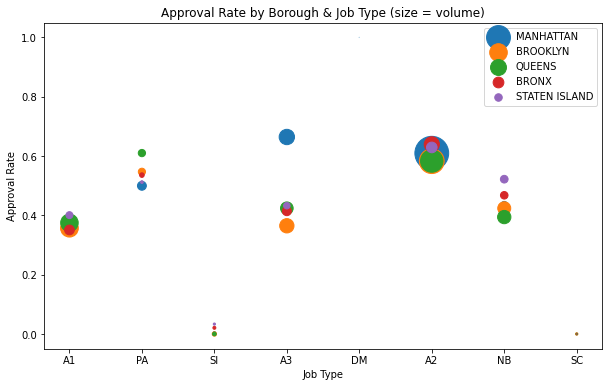

In [202]:
pdf = df_bt.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for b in pdf["borough"].unique():
    subset = pdf[pdf["borough"] == b]
    plt.scatter(
        subset["job_type"],
        subset["approval_rate"],
        s=subset["n"] / 50,
        label=b
    )

plt.legend()
plt.xlabel("Job Type")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Borough & Job Type (size = volume)")

plt.show()

### Insight 2: Approval Rate by Job Type: Brooklyn vs Manhattan

In [203]:
from pyspark.sql.functions import sum, count

df_bt = df_filtered.filter(col("borough").isin("BROOKLYN", "MANHATTAN")) \
    .groupBy("borough", "job_type") \
    .agg(
        (sum("target") / count("*")).alias("approval_rate"),
        count("*").alias("n")
    )

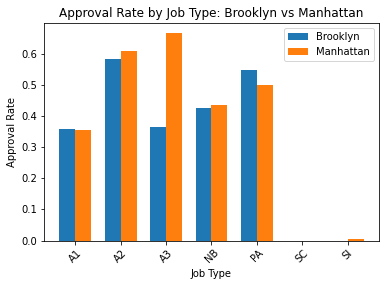

In [207]:
import matplotlib.pyplot as plt
import numpy as np

pdf = df_bt.toPandas()

pivot = pdf.pivot(index="job_type", columns="borough", values="approval_rate")
pivot = pivot.dropna()

job_types = pivot.index.tolist()
brooklyn = pivot["BROOKLYN"].values
manhattan = pivot["MANHATTAN"].values

x = np.arange(len(job_types))
width = 0.35

plt.figure()

plt.bar(x - width/2, brooklyn, width, label="Brooklyn")
plt.bar(x + width/2, manhattan, width, label="Manhattan")

plt.title("Approval Rate by Job Type: Brooklyn vs Manhattan")
plt.xlabel("Job Type")
plt.ylabel("Approval Rate")

plt.xticks(x, job_types, rotation=45)
plt.legend()

plt.show()


### Insight 3: Impact of flags on approval rate

In [199]:
from pyspark.sql.functions import col, avg, lit

systems = [
    "plumbing","mechanical","boiler","fuel_burning","fuel_storage",
    "standpipe","sprinkler","fire_alarm","equipment","fire_suppression","curb_cut"
]

dfs = []

for c in systems:
    tmp = df_filtered.groupBy(c).agg(
        avg("target").alias("approval_rate")
    ).filter(col(c) == "X") \
     .withColumn("feature", lit(c)) \
     .select("feature", "approval_rate")

    dfs.append(tmp)

final_df = dfs[0]
for d in dfs[1:]:
    final_df = final_df.union(d)

final_df.show()

+----------------+--------------------+
|         feature|       approval_rate|
+----------------+--------------------+
|        plumbing|  0.5207479764165085|
|      mechanical|  0.5313463224273959|
|          boiler|  0.6186003683241252|
|    fuel_burning|  0.7496688741721854|
|    fuel_storage|  0.6722614840989399|
|       standpipe| 0.48625130525583016|
|       sprinkler|  0.6399375711815076|
|      fire_alarm|0.022265939372261467|
|       equipment| 0.47367424242424244|
|fire_suppression|  0.3316582914572864|
|        curb_cut|   0.429891553383229|
+----------------+--------------------+



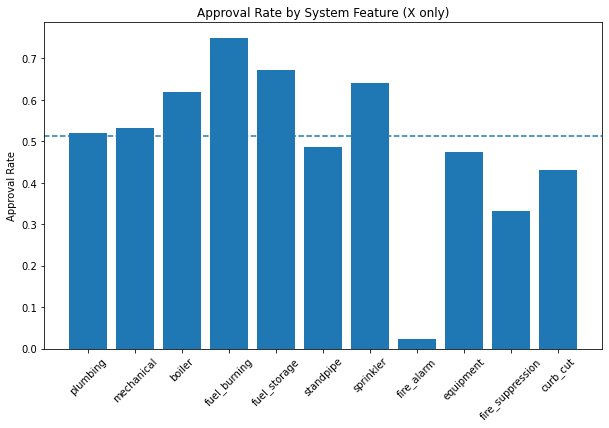

In [200]:
import matplotlib.pyplot as plt

pdf = final_df.toPandas()

plt.figure(figsize=(10,6))

plt.bar(pdf["feature"], pdf["approval_rate"])

# baseline
plt.axhline(y=baseline, linestyle='--')

plt.xticks(rotation=45)
plt.ylabel("Approval Rate")
plt.title("Approval Rate by System Feature (X only)")

plt.show()

### Insight 4: Approval Rate by Owner Type & Professional Certification

In [191]:
from pyspark.sql.functions import avg, count, col

df_combo = df_filtered.filter(col("professional_cert").isNotNull()) \
    .groupBy("professional_cert", "owner_type") \
    .agg(
        avg("target").alias("approval_rate"),
        count("*").alias("n")
    ) \
    .orderBy("approval_rate")

df_combo.show()

+-----------------+------------------+-------------------+-----+
|professional_cert|        owner_type|      approval_rate|    n|
+-----------------+------------------+-------------------+-----+
|                N|               HPD| 0.2845528455284553|  246|
|                N|        INDIVIDUAL|0.33589562281882257|43841|
|                N|             NYCHA| 0.3585237258347979|  569|
|                N|       CORPORATION|0.37247715893253497|38746|
|                N|       PARTNERSHIP|0.37412030831099197|23872|
|                N|             OTHER| 0.3753943217665615|  634|
|                N|              DCAS| 0.4482758620689655|  145|
|                N|          NY STATE| 0.4528301886792453|  106|
|                N|        NYC AGENCY|0.47815533980582525| 1236|
|                N|OTHER GOV'T AGENCY|0.48123436196830693| 2398|
|                N|               DOE|                0.5|   22|
|                N|               HHC| 0.5166666666666667|  120|
|                N|      

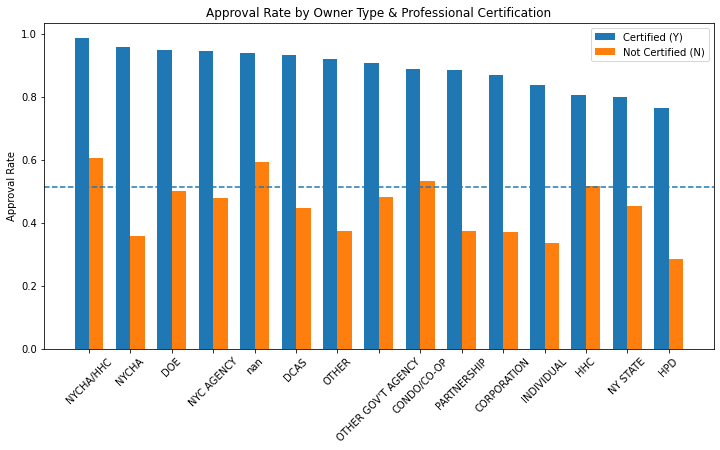

In [192]:
import matplotlib.pyplot as plt
import numpy as np


pdf = df_combo.toPandas()


pivot = pdf.pivot(index="owner_type", columns="professional_cert", values="approval_rate")

pivot = pivot.sort_values(by="Y", ascending=False)

x = np.arange(len(pivot.index))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, pivot["Y"], width, label="Certified (Y)")
plt.bar(x + width/2, pivot["N"], width, label="Not Certified (N)")

# baseline
plt.axhline(y=baseline, linestyle='--')

plt.xticks(x, pivot.index, rotation=45)
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Owner Type & Professional Certification")

plt.legend()
plt.show()

### Insight 5: Approval Rate by Construction Area

In [147]:
from pyspark.sql.functions import col, when, avg, count

df_area = df_filtered.withColumn(
    "area_bucket",
    when(col("total_construction_floor_area") == 0, "0")
    .when(col("total_construction_floor_area") < 1000, "<1k")
    .when(col("total_construction_floor_area") < 5000, "1k-5k")
    .when(col("total_construction_floor_area") < 20000, "5k-20k")
    .when(col("total_construction_floor_area") < 100000, "20k-100k")
    .otherwise("100k+")
)

df_area_agg = df_area.groupBy("area_bucket") \
    .agg(
        avg("target").alias("approval_rate"),
        count("*").alias("n")
    ) \
    .orderBy("area_bucket")

df_area_agg.show()

+-----------+-------------------+------+
|area_bucket|      approval_rate|     n|
+-----------+-------------------+------+
|          0| 0.5385154393174695|211214|
|      100k+|0.30602782071097373|  1294|
|      1k-5k|0.39303777281633023| 21947|
|   20k-100k|0.35066006600660066|  3636|
|     5k-20k| 0.3810563526720732|  9618|
|        <1k|0.43216783216783217|  4290|
+-----------+-------------------+------+



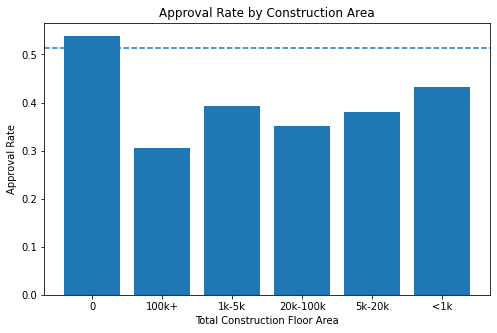

In [148]:
import matplotlib.pyplot as plt

pdf = df_area_agg.toPandas()

plt.figure(figsize=(8,5))

plt.bar(pdf["area_bucket"], pdf["approval_rate"])

# baseline
plt.axhline(y=baseline, linestyle='--')

plt.xlabel("Total Construction Floor Area")
plt.ylabel("Approval Rate")
plt.title("Approval Rate by Construction Area")

plt.show()

### Insight 6: Approval Rate vs Building Height

In [149]:
from pyspark.sql.functions import sum, count, col

df_stories = df_filtered.groupBy("proposed_no_of_stories") \
    .agg(
        (sum("target") / count("*")).alias("approval_rate"),
        count("*").alias("n")
    ) \
    .orderBy("proposed_no_of_stories")

df_stories.show()

+----------------------+-------------------+-----+
|proposed_no_of_stories|      approval_rate|    n|
+----------------------+-------------------+-----+
|                  0.00| 0.4882064758938421|61644|
|                  1.00|0.49082747010834377|23167|
|                  2.00| 0.4817410312459817|46662|
|                  3.00| 0.4698345922172292|31377|
|                  4.00| 0.4987160879758848|17914|
|                  5.00| 0.5336670055525142|12787|
|                  6.00| 0.5527234353437779|12319|
|                  7.00| 0.5323955669224212| 4692|
|                  8.00| 0.5327814569536424| 3020|
|                  9.00| 0.5440340909090909| 2112|
|                 10.00| 0.5517410495340853| 2039|
|                 11.00| 0.5866364665911665| 1766|
|                 12.00| 0.5564779874213837| 3975|
|                 13.00| 0.6097875080489376| 1553|
|                 14.00| 0.6082711085582998| 1741|
|                 15.00| 0.6761053154495777| 2013|
|                 16.00|  0.658

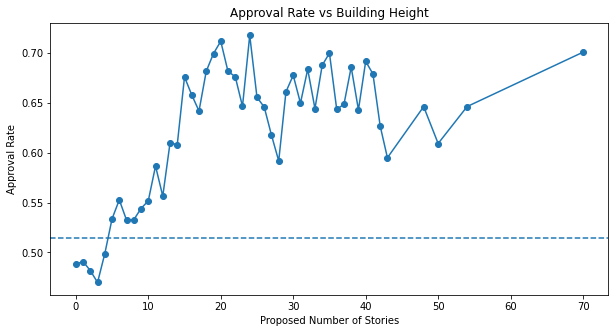

In [152]:
import matplotlib.pyplot as plt

df_stories_filtered = df_stories.filter(col("n") > 200)
pdf = df_stories_filtered.toPandas()

plt.figure(figsize=(10,5))

plt.plot(pdf["proposed_no_of_stories"], pdf["approval_rate"], marker='o')

# baseline
plt.axhline(y=baseline, linestyle='--')

plt.xlabel("Proposed Number of Stories")
plt.ylabel("Approval Rate")
plt.title("Approval Rate vs Building Height")

plt.show()

### Insight 7: Top Neighborhoods by Approval Rate

In [153]:
from pyspark.sql.functions import sum, count

df_geo = df_filtered.groupBy("gis_nta_name") \
    .agg(
        (sum("target") / count("*")).alias("approval_rate"),
        count("*").alias("cnt")
    ) \
    .filter("cnt > 1000") \
    .orderBy("approval_rate", ascending=False)

df_geo.show(10)

+--------------------+------------------+-----+
|        gis_nta_name|     approval_rate|  cnt|
+--------------------+------------------+-----+
|Turtle Bay-East M...|0.6535516801361123| 4702|
|           Yorkville|0.6528813559322034| 1475|
|            Gramercy|0.6426271732131359| 1553|
| Morningside Heights|0.6345347862531433| 1193|
|   East Harlem South|0.6222222222222222| 1260|
|      Lincoln Square|0.6193921852387844| 2073|
|Lenox Hill-Roosev...| 0.618140589569161| 2205|
|Murray Hill-Kips Bay|0.6119151800740491| 2971|
|Midtown-Midtown S...|0.6092773702798153|14724|
|Battery Park City...|0.6069021850112314| 4897|
+--------------------+------------------+-----+
only showing top 10 rows



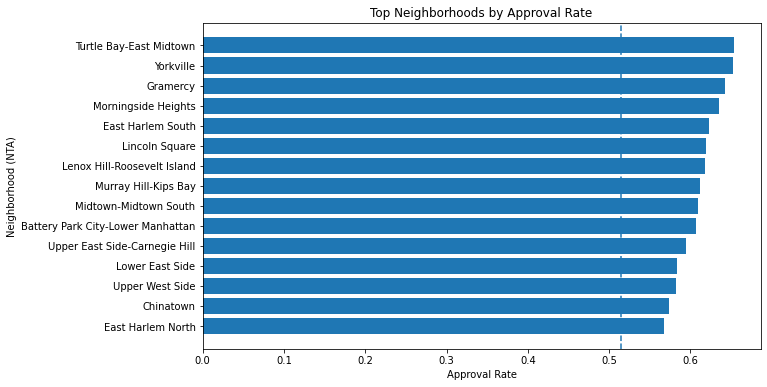

In [156]:
import matplotlib.pyplot as plt

pdf = df_geo.toPandas()
pdf_top = pdf.head(15)

plt.figure(figsize=(10,6))

plt.barh(pdf_top["gis_nta_name"], pdf_top["approval_rate"])

# baseline
plt.axvline(x=baseline, linestyle='--')

plt.xlabel("Approval Rate")
plt.ylabel("Neighborhood (NTA)")
plt.title("Top Neighborhoods by Approval Rate")

plt.gca().invert_yaxis()

plt.show()